<a href="https://colab.research.google.com/github/Band3er/course-proj-VR/blob/main/ACV_69170_lab4_part_24_sol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratory Session 4: Diffusion models for computer vision**
**Date:** 2 April 2025
   
**Authors**: Jesús Bermúdez Cameo y Alejandro Pérez Yus

**Version:** 1.0

In this lab session we want to explore the mechanisms behind diffusion models for generating, modifying images and connecting them with computer vision inference.

Goals of the assignment:
1.	Understanding Denoising Diffusion Probabilistic Models (DDPM)
2.	Understanding the Latent diffusion models pipeline
3.	Exploring diffusion model applications like depth estimation
4.  Learn to modify whole images and replace masked objects with text prompts

### 2.4 Diffusion models using depth for guiding text-to-image

In this section we are going to test Marigold, a Diffusion model for monocular depth estimation (see https://marigoldmonodepth.github.io) and use this depth as input for ControlNet in a text-to-image-generation pipeline.

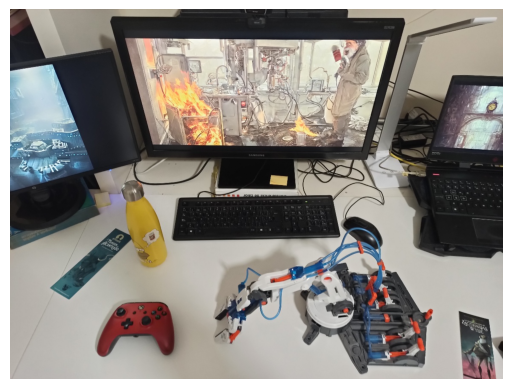

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

input_image = Image.open('/content/IMG_20250308_194103.jpg').convert('RGB')

plt.figure()
plt.imshow(input_image)
plt.axis('off')
plt.show()

In [ ]:
import torch
import diffusers


device = "cuda"
generator = torch.Generator(device=device).manual_seed(2024)
image = input_image


pipe = diffusers.MarigoldDepthPipeline.from_pretrained(
    "prs-eth/marigold-depth-lcm-v1-0", torch_dtype=torch.float16, variant="fp16"
).to(device)

depth_image = pipe(image, generator=generator).prediction
depth_image_c = pipe.image_processor.visualize_depth(depth_image, color_map="binary")
depth_image_c[0].save("controlnet_depth.png")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/824 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/633 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Marigold predictions...:   0%|          | 0/1 [00:00<?, ?it/s]

Diffusion steps...:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
depth_image[0].shape

(868, 1156, 1)

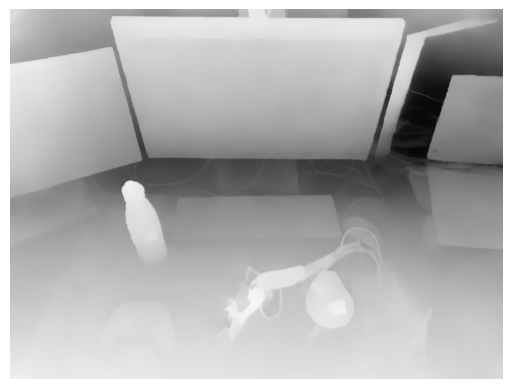

In [ ]:
plt.figure()
plt.imshow(depth_image_c[0])
plt.axis('off')
plt.show()

In [ ]:
torch.cuda.synchronize()
del pipe
torch.cuda.empty_cache()

In [ ]:
controlnet = diffusers.ControlNetModel.from_pretrained(
    "diffusers/controlnet-depth-sdxl-1.0", torch_dtype=torch.float16, variant="fp16"
).to(device)
pipe = diffusers.StableDiffusionXLControlNetPipeline.from_pretrained(
    "SG161222/RealVisXL_V4.0", torch_dtype=torch.float16, variant="fp16", controlnet=controlnet
).to(device)
pipe.scheduler = diffusers.DPMSolverMultistepScheduler.from_config(pipe.scheduler.config, use_karras_sigmas=True)

controlnet_out = pipe(
    prompt="A cluttered, modern desktop workspace. Ultra-Realistic style. Geeky tech lab.a small hydraulic robotic arm toy with blue tubes and white plastic parts.",
    negative_prompt="",
    guidance_scale=6.5,
    num_inference_steps=25,
    image=depth_image_c,
    controlnet_conditioning_scale=0.7,
    control_guidance_end=0.7,
    generator=generator,
).images
controlnet_out[0].save("controlnet_out.png")

config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/602 [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/5.14G [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

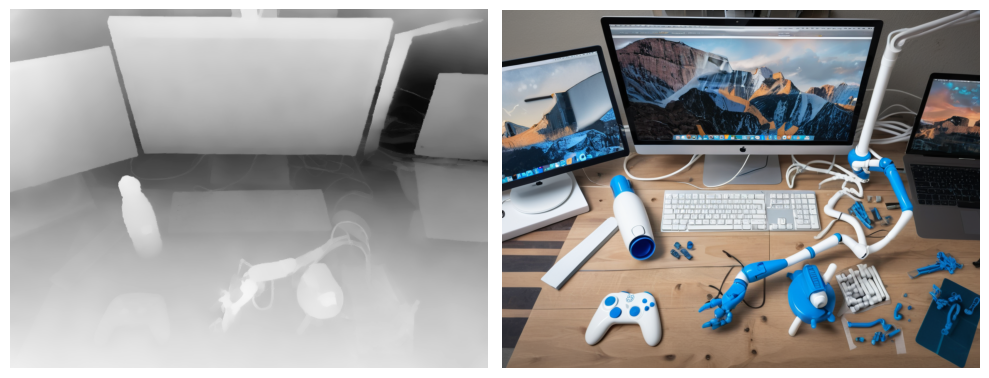

In [ ]:
[figs, axis] = plt.subplots(1,2,figsize=(10,20))

controlnet_depth = Image.open('/content/controlnet_depth.png').convert('RGB')
controlnet_out = Image.open('/content/controlnet_out.png').convert('RGB')

axis[0].imshow(controlnet_depth)
axis[0].axis('off')
axis[1].imshow(controlnet_out)
axis[1].axis('off')
plt.tight_layout()

